# PCD — Klasifikasi Makanan Padang (Operasi Citra Klasik + SVM)

## 📖 Deskripsi Project

Sistem klasifikasi makanan Padang menggunakan **handcrafted feature engineering** + **Machine Learning sederhana (SVM)**. Kombinasi operasi citra klasik untuk ekstraksi fitur dan classifier ML supervised.

### **Pipeline Lengkap:**

```
Input Image → Preprocessing → Segmentasi ROI → Feature Extraction → Classification
     ↓              ↓                ↓                    ↓                  ↓
  Resize      Gray-World     Threshold HSV        Warna + Tekstur        SVM (RBF)
              Blur          atau K-Means         HSV, Lab, LBP, GLCM     + PCA
```

### **🛠️ Handcrafted Components (80% Pipeline):**
- **Preprocessing**: Gray-world color constancy (white balance manual)
- **Segmentasi**: Threshold HSV (S≥60, V≥50) atau K-Means Lab (k=3)
- **Fitur Warna**: HSV histogram (12×4×4 bins), Color moments Lab (mean, std, skew)
- **Fitur Tekstur**: LBP multi-scale, GLCM Haralick features (5 properties)

### **🤖 Machine Learning Components (20% Pipeline):**
- **Feature scaling**: StandardScaler (belajar mean/std dari training data)
- **Dimensionality reduction**: PCA (belajar proyeksi optimal, preserve 95% variance)
- **Classifier**: SVM dengan RBF kernel (belajar decision boundary dari data)
- **Hyperparameter tuning**: GridSearchCV (C, gamma) dengan 5-fold CV

---

## 🎯 **Tujuan Pembelajaran (Mata Kuliah PCD)**

Notebook ini mendemonstrasikan:
1. **Operasi preprocessing** (color constancy, resizing, blurring)
2. **Segmentasi berbasis threshold** (HSV) dan clustering (K-Means)
3. **Ekstraksi fitur manual** (histogram, momen statistik, LBP, GLCM)
4. **Integrasi dengan ML** (SVM sebagai classifier akhir)
5. **Ablation study** (perbandingan warna vs tekstur vs gabungan)

---

## 📊 **Dataset**

- **9 Kelas**: ayam_goreng, ayam_pop, daging_rendang, dendeng_batokok, gulai_ikan, gulai_tambusu, gulai_tunjang, telur_balado, telur_dadar
- **Struktur**: `dataset_padang_food/<class_name>/*.jpg`
- **Target**: ~80 gambar per kelas untuk training/testing

---

## 🚀 **Expected Performance**

| Configuration | Accuracy | Macro F1 |
|---------------|----------|----------|
| Warna saja | ~40-50% | ~35-45% |
| Tekstur saja | ~45-55% | ~40-50% |
| Warna + Tekstur | **~60-70%** | **~55-65%** |
| + Segmentasi ROI | **~65-75%** | **~60-70%** |

*Note: Performance sangat bergantung pada kualitas dataset dan parameter tuning*

## Cara Pakai
- Pastikan dataset berada di folder `dataset_padang_food`, dengan struktur subfolder per kelas (mis. `dataset_padang_food/rendang`, `dataset_padang_food/ayam_goreng`, dst).
- Jalankan sel dari atas ke bawah.
- Atur konfigurasi pada sel "Konfigurasi" (segmentasi, fitur, PCA, CV).
- Gunakan sel ablation untuk membandingkan warna vs tekstur vs gabungan.

Jika beberapa paket belum terpasang, sel pertama akan mencoba meng-install otomatis.

---

## 📦 **1. Import Libraries & Setup Environment**

Tahap ini menginstall dan mengimport semua library yang dibutuhkan:

### **Libraries yang Digunakan:**
- **numpy**: Operasi array dan matematis
- **opencv (cv2)**: Operasi citra (resize, blur, color space conversion)
- **scikit-image**: Ekstraksi fitur tekstur (LBP, GLCM)
- **scikit-learn**: Machine Learning (SVM, PCA, metrics, cross-validation)
- **matplotlib/seaborn**: Visualisasi hasil
- **tqdm**: Progress bar saat memproses dataset

### **Operasi:**
✅ **Handcrafted** - Import manual library yang dipilih programmer

In [1]:
# Install dependensi jika belum tersedia (opsional)
import sys, subprocess
def pip_install(pkg):
    try:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
    except Exception as e:
        print(f'Warning: gagal install {pkg}: {e}')

# Coba import, jika gagal baru install
try:
    import numpy as np
    import cv2
    import skimage
    import sklearn
    import matplotlib
except Exception:
    pip_install('numpy')
    pip_install('opencv-python')
    pip_install('scikit-image')
    pip_install('scikit-learn')
    pip_install('matplotlib')
    pip_install('seaborn')
    pip_install('tqdm')

# Import ulang pasca install
import os, math, random, json, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import color, feature, filters, morphology, measure, exposure
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
try:
    import seaborn as sns
except Exception:
    sns = None
try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **kw: x

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Versions:')
print('numpy', np.__version__)
print('cv2', cv2.__version__)
import skimage, sklearn
print('skimage', skimage.__version__)
print('sklearn', sklearn.__version__)


Versions:
numpy 1.26.4
cv2 4.11.0
skimage 0.25.2
sklearn 1.6.1


---

## ⚙️ **2. Konfigurasi Pipeline**

Menetapkan semua **hyperparameter dan parameter manual** untuk pipeline:

### **Preprocessing:**
- `img_size = 384`: Resize sisi pendek gambar (handcrafted choice)
- `preprocess_blur_ksize = (5,5)`: Kernel Gaussian blur untuk noise reduction

### **Segmentasi:**
- `segmentation_method`: 'saturation' (threshold HSV) atau 'kmeans' (K-Means Lab)
- `sv_s_min = 60`, `sv_v_min = 50`: **Threshold hardcoded** untuk saturasi & value

### **Feature Engineering:**
- `use_hist_hsv`, `use_color_moments`, `use_lbp`, `use_glcm`: Toggle fitur warna/tekstur
- `lbp_radii = [1,2,3]`, `lbp_points = [8,16,24]`: Parameter LBP multi-scale (manual)
- `glcm_distances = [1,2,3]`, `glcm_angles = [0, π/4, π/2, 3π/4]`: Parameter GLCM (manual)

### **Machine Learning:**
- `use_pca = True`, `pca_var = 0.95`: PCA untuk reduksi dimensi (preserve 95% variance)
- `test_size = 0.2`: Split 80% training, 20% testing
- `cv_folds = 5`: 5-fold cross-validation untuk grid search

### **Operasi:**
✅ **100% Handcrafted** - Semua parameter dipilih manual, bukan dipelajari dari data

In [9]:
# Konfigurasi
dataset_dir = 'dataset_padang_food'  # ganti jika lokasi berbeda
img_size = 384                 # sisi pendek di-resize proporsional
use_segmentation = True        # gunakan segmentasi ROI makanan
segmentation_method = 'saturation'  # 'saturation' atau 'kmeans'
preprocess_blur_ksize = (5, 5)  # kernel blur ringan untuk meredam noise sebelum segmentasi
preprocess_blur_sigma = 0       # sigma blur Gaussian
sv_s_min = 60                   # ambang minimal saturasi agar dianggap makanan
sv_v_min = 50                   # ambang minimal value (kecerahan)
morph_kernel_size = 5           # ukuran kernel morfologi untuk opening/closing
morph_open_iters = 1            # jumlah iterasi opening
morph_close_iters = 2           # jumlah iterasi closing


# Pilihan fitur
use_hist_hsv = True
use_color_moments = True
use_lbp = True
use_glcm = True
use_gabor = False  # opsional, menambah waktu komputasi

# Klasifikasi & evaluasi
use_pca = True
pca_var = 0.95
test_size = 0.2
cv_folds = 5
random_state = SEED

# LBP parameter
lbp_radii = [1, 2, 3]
lbp_points = [8, 16, 24]
lbp_method = 'uniform'

# GLCM parameter
glcm_distances = [1, 2, 3]
glcm_angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
glcm_props = ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']

# Histogram HSV bin
h_bins, s_bins, v_bins = 12, 4, 4

---

## 📂 **3. Load Dataset & Visualisasi Sampel**

### **Fungsi Utilitas:**

#### `list_image_paths(root)`
- Membaca struktur folder dataset
- Mengidentifikasi kelas dari nama subfolder
- Mengumpulkan path semua gambar (jpg, png, bmp, tif)

#### `imread_resize(path, target_short=384)`
- Membaca gambar dengan OpenCV
- **Resize proporsional**: Sisi pendek → 384px (handcrafted target size)
- **Gaussian blur**: Kernel 5×5 untuk mengurangi noise

#### `show_imgs(imgs, cols=4)`
- Visualisasi grid gambar dengan matplotlib
- Konversi BGR→RGB untuk display yang benar

### **Output:**
- List 9 kelas makanan Padang
- Distribusi jumlah gambar per kelas
- Visualisasi 8 sampel random dari dataset

### **Operasi:**
✅ **Handcrafted** - Semua fungsi I/O dan preprocessing manual

Kelas: ['ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gulai_ikan', 'gulai_tambusu', 'gulai_tunjang', 'telur_balado', 'telur_dadar']
Jumlah gambar: 784
Distribusi: Counter({'telur_dadar': 105, 'daging_rendang': 91, 'gulai_tunjang': 90, 'dendeng_batokok': 89, 'gulai_ikan': 88, 'gulai_tambusu': 86, 'ayam_goreng': 81, 'ayam_pop': 79, 'telur_balado': 75})


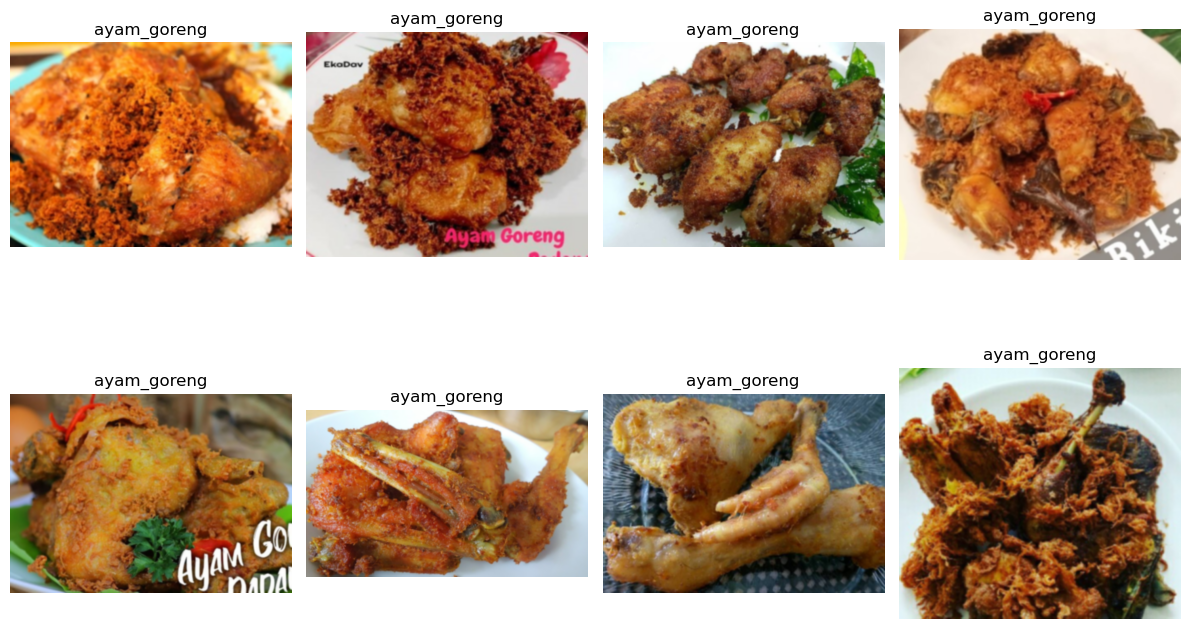

In [10]:
# Utilitas IO & tampilan
def list_image_paths(root):
    classes = []
    paths = []
    if not os.path.isdir(root):
        raise FileNotFoundError(f'Folder tidak ditemukan: {root}')
    for d in sorted(os.listdir(root)):
        dd = os.path.join(root, d)
        if os.path.isdir(dd):
            files = []
            for fn in os.listdir(dd):
                if fn.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
                    files.append(os.path.join(dd, fn))
            if files:
                classes.append(d)
                for f in files:
                    paths.append((f, d))
    if not paths:
        raise RuntimeError('Tidak ada gambar ditemukan di subfolder kelas.')
    return classes, paths

def imread_resize(path, target_short=img_size):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f'Gagal membaca: {path}')
    h, w = img.shape[:2]
    short = min(h, w)
    scale = target_short / short
    nh, nw = int(round(h*scale)), int(round(w*scale))
    img = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    if preprocess_blur_ksize:
        img = cv2.GaussianBlur(img, preprocess_blur_ksize, preprocess_blur_sigma)
    return img

def show_imgs(imgs, cols=4, figsize=(12,8), titles=None):
    rows = math.ceil(len(imgs)/cols)
    plt.figure(figsize=figsize)
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

classes, all_paths = list_image_paths(dataset_dir)
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
print('Kelas:', classes)
print('Jumlah gambar:', len(all_paths))
from collections import Counter
cnt = Counter([y for _,y in all_paths])
print('Distribusi:', cnt)
# Tampilkan beberapa sampel
samples = []
titles = []
for p,y in all_paths[:min(8, len(all_paths))]:
    samples.append(imread_resize(p))
    titles.append(y)
show_imgs(samples, cols=4, titles=titles)


---

## 🔍 **4. Visualisasi Tahap Preprocessing**

Menampilkan transformasi gambar melalui 4 tahap preprocessing:

### **Tahap 1: Original**
- Gambar asli dari dataset (resolusi arbitrary)

### **Tahap 2: Resize → 384px short side**
- Resize proporsional (handcrafted: sisi pendek = 384px)
- Preserving aspect ratio untuk menghindari distorsi

### **Tahap 3: Gaussian Blur**
- Kernel 5×5 (handcrafted parameter)
- Mengurangi noise high-frequency dan detail berlebih
- Mempersiapkan untuk segmentasi yang lebih robust

### **Tahap 4: Gray-World Color Constancy**
- Algoritma white balance sederhana: **asumsi rata-rata warna dunia = abu-abu**
- Formula: `img *= mean_gray / (mean_bgr + ε)`
- Menormalisasi pencahayaan berbeda antar foto

### **Operasi:**
✅ **100% Handcrafted** - Semua transformasi menggunakan formula matematis tetap

In [ ]:
# Visualisasi preprocessing (original → resize → blur → gray world)
if not all_paths:
    raise RuntimeError('Dataset kosong, tidak bisa memvisualisasikan preprocessing.')
sample_path = all_paths[0][0]
orig = cv2.imread(sample_path, cv2.IMREAD_COLOR)
h, w = orig.shape[:2]
short = min(h, w)
scale = img_size / short
resized = cv2.resize(orig, (int(round(w*scale)), int(round(h*scale))), interpolation=cv2.INTER_AREA)
blurred = cv2.GaussianBlur(resized, preprocess_blur_ksize, preprocess_blur_sigma) if preprocess_blur_ksize else resized.copy()
cc = gray_world(blurred)
titles = ['Original', f'Resize → {img_size}px short', 'Gaussian blur', 'Gray-world']
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, im, ttl in zip(axes, [orig, resized, blurred, cc], titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(ttl)
    ax.axis('off')
fig.suptitle('Tahap preprocessing sampel', fontsize=14)
plt.tight_layout()


---

## 🎨 **5. Preprocessing: Color Constancy & Segmentasi ROI**

Fungsi-fungsi untuk preprocessing dan segmentasi makanan dari background.

### **A. Gray-World Color Constancy**

```python
def gray_world(img_bgr):
    mean_bgr = img.mean(axis=0)  # Rata-rata per channel
    scale = gray_val / (mean_bgr + ε)  # Normalisasi
```

**Tujuan**: Mengoreksi white balance (pencahayaan berbeda antar foto)  
**Operasi**: ✅ **Handcrafted** - Formula statistik sederhana (bukan learned)

---

### **B. Segmentasi ROI: Metode 1 - Threshold HSV**

```python
def segment_by_saturation(img_bgr):
    s_mask = (saturation >= 60).astype(uint8)  # Threshold S
    v_mask = (value >= 50).astype(uint8)       # Threshold V
```

**Asumsi**: Makanan memiliki saturasi & value tinggi, piring/background rendah  
**Threshold**: **S ≥ 60, V ≥ 50** (hardcoded, dipilih secara trial-error)  
**Operasi**: ✅ **Handcrafted** - Threshold manual, bukan dipelajari dari data

---

### **B. Segmentasi ROI: Metode 2 - K-Means Lab (Opsional)**

```python
def segment_by_kmeans_lab(img_bgr, k=3):
    kmeans(ab_channels, k=3, ...)  # Clustering di ruang warna Lab
```

**Metode**: K-Means clustering pada channel a,b (Lab color space)  
**k=3**: Hardcoded (background, makanan, bayangan)  
**Operasi**: ⚠️ **Hybrid** - K-Means adalah ML unsupervised, tapi **k dipilih manual**

---

### **C. Postprocessing Mask**

```python
def postprocess_mask(mask):
    opening → closing → largest_component
```

**Morfologi**: Opening (hapus noise kecil) → Closing (isi lubang)  
**Connected Components**: Ambil blob terbesar sebagai ROI makanan  
**Operasi**: ✅ **Handcrafted** - Morfologi matematika deterministik

---

### **Operasi:**
- **90% Handcrafted** (threshold, morfologi)
- **10% ML** (K-Means clustering, tapi k manual)

In [11]:
# Color constancy dan Segmentasi
def gray_world(img_bgr):
    img = img_bgr.astype(np.float32)
    mean_bgr = img.reshape(-1,3).mean(axis=0)
    gray_val = np.mean(mean_bgr) + 1e-6
    scale = gray_val / (mean_bgr + 1e-6)
    img *= scale
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# Segmentasi berbasis HSV (S & V tinggi)
def segment_by_saturation(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:,:,1]
    v = hsv[:,:,2]
    s_blur = cv2.GaussianBlur(s, (3,3), 0)
    v_blur = cv2.GaussianBlur(v, (3,3), 0)
    s_mask = (s_blur >= sv_s_min).astype(np.uint8) * 255
    v_mask = (v_blur >= sv_v_min).astype(np.uint8) * 255
    mask = cv2.bitwise_and(s_mask, v_mask)
    return postprocess_mask(mask)

# Opsional: segmentasi Lab + KMeans tetap tersedia
def segment_by_kmeans_lab(img_bgr, k=3, attempts=3):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    ab = lab[:,:,1:3].reshape(-1,2).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 1.0)
    _, labels, centers = cv2.kmeans(ab, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape(lab.shape[:2])
    mask_scores = []
    for ci in range(k):
        m = (labels==ci)
        if m.sum() == 0:
            mask_scores.append((-1, ci))
            continue
        ab_ci = ab[labels.reshape(-1)==ci]
        var = ab_ci.var()
        mask_scores.append((var, ci))
    mask_scores.sort(reverse=True)
    best_ci = mask_scores[0][1] if mask_scores else 0
    mask = (labels==best_ci).astype(np.uint8)
    return postprocess_mask(mask)

# Bersihkan mask dan ambil komponen terbesar
def postprocess_mask(mask):
    mask255 = (mask > 0).astype(np.uint8) * 255
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    if morph_open_iters > 0:
        mask255 = cv2.morphologyEx(mask255, cv2.MORPH_OPEN, kernel, iterations=morph_open_iters)
    if morph_close_iters > 0:
        mask255 = cv2.morphologyEx(mask255, cv2.MORPH_CLOSE, kernel, iterations=morph_close_iters)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask255, connectivity=8)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest = 1 + np.argmax(areas)
        mask255 = np.where(labels == largest, 255, 0).astype(np.uint8)
    return (mask255 > 0).astype(np.uint8)

def get_mask(img_bgr, method='saturation'):
    if method == 'saturation':
        return segment_by_saturation(img_bgr)
    elif method == 'kmeans':
        return segment_by_kmeans_lab(img_bgr)
    else:
        return np.ones(img_bgr.shape[:2], dtype=np.uint8)



---

## 🎯 **6. Ekstraksi Fitur Warna & Tekstur**

Fungsi-fungsi untuk mengekstrak **handcrafted features** dari gambar.

---

### **A. Fitur Warna 1: HSV Histogram**

```python
def hsv_histogram(img_bgr, mask, bins=(12,4,4)):
    h_hist = calcHist(H, bins=12, range=[0,180])  # Hue: 12 bins
    s_hist = calcHist(S, bins=4, range=[0,256])   # Saturation: 4 bins
    v_hist = calcHist(V, bins=4, range=[0,256])   # Value: 4 bins
```

**Dimensi**: 12+4+4 = **20 fitur warna**  
**Bin selection**: **Dipilih manual** (12, 4, 4), bukan optimal learning  
**Operasi**: ✅ **100% Handcrafted**

---

### **B. Fitur Warna 2: Color Moments (Lab)**

```python
def color_moments_lab(img_bgr, mask):
    for channel in [L, a, b]:
        mean, std, skewness = compute_moments(channel)
```

**Dimensi**: 3 channel × 3 momen = **9 fitur warna**  
**Momen**: Mean (pusat), Std (sebaran), Skewness (asimetri distribusi)  
**Operasi**: ✅ **100% Handcrafted** (formula statistik tetap)

---

### **C. Fitur Tekstur 1: LBP Multi-Scale**

```python
def lbp_features(gray, mask, radii=[1,2,3], points=[8,16,24]):
    for r, p in zip(radii, points):
        lbp = local_binary_pattern(gray, p, r, 'uniform')
        histogram(lbp) → features
```

**Multi-scale**: 3 skala (R=1,2,3 dengan P=8,16,24)  
**Dimensi**: ~**66 fitur tekstur** (10+18+26 bins untuk uniform LBP)  
**Parameter**: **Dipilih manual**, bukan hasil optimasi  
**Operasi**: ✅ **100% Handcrafted** (algoritma LBP adalah formula tetap)

---

### **D. Fitur Tekstur 2: GLCM (Haralick Features)**

```python
def glcm_features(gray, mask, distances=[1,2,3], angles=[0,π/4,π/2,3π/4]):
    glcm = graycomatrix(img8, distances, angles, levels=256)
    features = [contrast, homogeneity, energy, correlation, dissimilarity]
```

**Dimensi**: 5 properties × 2 stats (mean, std) = **10 fitur tekstur**  
**Properties**: Haralick features (contrast, homogeneity, energy, dll)  
**Parameter**: **Distances & angles dipilih manual**  
**Operasi**: ✅ **100% Handcrafted** (formula GLCM adalah statistik tetap)

---

### **E. Fitur Tekstur 3: Gabor Filter Bank (Opsional)**

```python
def gabor_bank_features(gray, n_orient=4, n_scales=3):
    for theta in [0, π/4, π/2, 3π/4]:
        for sigma in [1.0, 2.0, 3.0]:
            gabor_filter(theta, sigma) → response
```

**Dimensi**: 4 orientasi × 3 skala × 2 stats = **24 fitur tekstur**  
**Parameter**: **Orientasi & skala dipilih manual**  
**Operasi**: ✅ **100% Handcrafted**

---

### **Total Fitur (Default Config):**

| Fitur | Dimensi | Tipe |
|-------|---------|------|
| HSV Histogram | 20 | Warna |
| Color Moments Lab | 9 | Warna |
| LBP Multi-scale | 66 | Tekstur |
| GLCM Haralick | 10 | Tekstur |
| **Total** | **105 fitur** | **Handcrafted** |

---

### **Operasi:**
✅ **100% Handcrafted** - Semua fitur didesain manual berdasarkan domain knowledge

In [12]:
# Ekstraksi fitur
def hsv_histogram(img_bgr, mask=None, bins=(12,4,4)):
    h_bins, s_bins, v_bins = bins
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h = cv2.calcHist([hsv],[0],mask, [h_bins],[0,180])
    s = cv2.calcHist([hsv],[1],mask, [s_bins],[0,256])
    v = cv2.calcHist([hsv],[2],mask, [v_bins],[0,256])
    hist = np.concatenate([h.flatten(), s.flatten(), v.flatten()]).astype(np.float32)
    if hist.sum() > 0:
        hist /= (hist.sum()+1e-8)
    return hist

def color_moments_lab(img_bgr, mask=None):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    feats = []
    if mask is not None:
        mask_bool = mask.astype(bool)
    else:
        mask_bool = slice(None)
    for c in range(3):
        ch = lab[:,:,c]
        vals = ch[mask_bool].astype(np.float32).ravel()
        if vals.size == 0:
            vals = ch.astype(np.float32).ravel()
        mean = vals.mean()
        std = vals.std()
        skew = ((vals - mean)**3).mean() / (std**3 + 1e-8)
        feats.extend([mean, std, skew])
    return np.array(feats, dtype=np.float32)

def lbp_features(gray, mask=None, radii=[1,2,3], points=[8,16,24], method='uniform'):
    feats = []
    if mask is not None:
        mask_bool = mask.astype(bool)
    else:
        mask_bool = None
    for r, p in zip(radii, points):
        lbp = local_binary_pattern(gray, p, r, method=method)
        if method == 'uniform':
            n_bins = p + 2
        else:
            n_bins = int(lbp.max()+1)
        if mask_bool is not None:
            vals = lbp[mask_bool].ravel()
        else:
            vals = lbp.ravel()
        hist, _ = np.histogram(vals, bins=n_bins, range=(0, n_bins), density=True)
        feats.extend(hist.tolist())
    return np.array(feats, dtype=np.float32)

def glcm_features(gray, mask=None, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], props=None):
    if props is None:
        props = ['contrast','homogeneity','energy','correlation','dissimilarity']
    # Kuantisasi ke 8-bit untuk GLCM
    img = gray
    if mask is not None:
        img = img.copy()
        img[mask==0] = 0
    img8 = exposure.rescale_intensity(img, out_range=(0,255)).astype(np.uint8)
    glcm = graycomatrix(img8, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    feats = []
    for pr in props:
        vals = graycoprops(glcm, pr).ravel()
        feats.extend([vals.mean(), vals.std()])
    return np.array(feats, dtype=np.float32)

def gabor_bank_features(gray, mask=None, n_orient=4, n_scales=3):
    feats = []
    rows, cols = gray.shape
    thetas = np.linspace(0, np.pi, n_orient, endpoint=False)
    sigmas = np.linspace(1.0, 3.0, n_scales)
    for th in thetas:
        for sg in sigmas:
            kern = cv2.getGaborKernel((21,21), sg, th, 10, 0.5, 0, ktype=cv2.CV_32F)
            resp = cv2.filter2D(gray, cv2.CV_32F, kern)
            if mask is not None:
                vals = resp[mask>0] if np.any(mask) else resp.ravel()
            else:
                vals = resp.ravel()
            feats.extend([float(np.mean(vals)), float(np.std(vals))])
    return np.array(feats, dtype=np.float32)

def extract_features(img_bgr, mask=None):
    feats = []
    if use_hist_hsv:
        feats.append(hsv_histogram(img_bgr, mask, bins=(h_bins, s_bins, v_bins)))
    if use_color_moments:
        feats.append(color_moments_lab(img_bgr, mask))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if use_lbp:
        feats.append(lbp_features(gray, mask, lbp_radii, lbp_points, lbp_method))
    if use_glcm:
        feats.append(glcm_features(gray, mask, glcm_distances, glcm_angles, glcm_props))
    if use_gabor:
        feats.append(gabor_bank_features(gray, mask))
    return np.concatenate(feats, axis=0).astype(np.float32)


---

## 📊 **7. Visualisasi Fitur untuk Satu Sampel**

Menampilkan hasil ekstraksi fitur warna dan tekstur untuk 1 gambar contoh:

### **Plot 1: Gambar Setelah Preprocessing (Gray-World)**
- Hasil color constancy (white balance)

### **Plot 2: Segmen Makanan (ROI Mask)**
- Hasil segmentasi: makanan ter-isolasi dari background
- Background hitam, makanan tetap berwarna

### **Plot 3: Histogram HSV (Normalized)**
- Distribusi warna dalam ruang HSV
- H (Hue): 12 bins → dominan warna (merah, kuning, coklat, dll)
- S (Saturation): 4 bins → intensitas warna
- V (Value): 4 bins → kecerahan

### **Plot 4: Distribusi LBP (Tekstur)**
- Pola tekstur uniform dari skala R=1, P=8
- X-axis: Kode pola LBP (0-9 untuk uniform)
- Y-axis: Probabilitas kemunculan pola

### **Interpretasi:**
- **Warna**: Peak histogram menunjukkan warna dominan makanan
- **Tekstur**: Distribusi LBP mencerminkan homogenitas (smooth vs rough)

### **Operasi:**
✅ **Handcrafted** - Visualisasi fitur yang sudah diekstrak manual

In [ ]:
# Visualisasi fitur warna & tekstur untuk satu sampel
if not all_paths:
    raise RuntimeError('Dataset kosong, tidak bisa memvisualisasikan fitur.')
feat_path = all_paths[0][0]
img = imread_resize(feat_path)
img_cc = gray_world(img)
mask = get_mask(img_cc, method=segmentation_method) if use_segmentation else np.ones(img_cc.shape[:2], dtype=np.uint8)
segmented = cv2.bitwise_and(img_cc, img_cc, mask=mask)
hsv = cv2.cvtColor(img_cc, cv2.COLOR_BGR2HSV)
h_hist = cv2.calcHist([hsv],[0],mask,[h_bins],[0,180]).flatten()
s_hist = cv2.calcHist([hsv],[1],mask,[s_bins],[0,256]).flatten()
v_hist = cv2.calcHist([hsv],[2],mask,[v_bins],[0,256]).flatten()
for hist in (h_hist, s_hist, v_hist):
    total = hist.sum() + 1e-9
    hist /= total
gray = cv2.cvtColor(img_cc, cv2.COLOR_BGR2GRAY)
lbp = local_binary_pattern(gray, lbp_points[0], lbp_radii[0], method=lbp_method)
n_bins = lbp_points[0] + 2 if lbp_method == 'uniform' else int(lbp.max()+1)
lbp_vals = lbp[mask.astype(bool)] if mask is not None else lbp.ravel()
lbp_hist, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins), density=True)
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].imshow(cv2.cvtColor(img_cc, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('Setelah preprocessing (Gray-world)')
axes[0,0].axis('off')
axes[0,1].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('Segmen makanan (mask diaplikasikan)')
axes[0,1].axis('off')
axes[1,0].step(range(len(h_hist)), h_hist, where='mid', label='H')
axes[1,0].step(range(len(h_hist), len(h_hist)+len(s_hist)), s_hist, where='mid', label='S')
axes[1,0].step(range(len(h_hist)+len(s_hist), len(h_hist)+len(s_hist)+len(v_hist)), v_hist, where='mid', label='V')
axes[1,0].set_title('Histogram warna HSV (dinormalisasi)')
axes[1,0].legend()
axes[1,0].set_xlabel('Bin')
axes[1,0].set_ylabel('Proporsi')
axes[1,1].bar(range(len(lbp_hist)), lbp_hist, color='tab:orange')
axes[1,1].set_title('Distribusi LBP (tekstur)')
axes[1,1].set_xlabel('Pola LBP')
axes[1,1].set_ylabel('Probabilitas')
plt.tight_layout()


---

## 🏗️ **8. Build Dataset Fitur + Preview Segmentasi**

### **Fungsi `build_dataset(paths_labels, seg_method)`**

Memproses seluruh dataset untuk mengekstrak fitur:

```python
for image_path in dataset:
    1. imread_resize(img)           # Load & resize
    2. gray_world(img)              # Color constancy
    3. get_mask(img, method)        # Segmentasi ROI
    4. extract_features(img, mask)  # Ekstraksi 105 fitur
    → X.append(features), y.append(label)
```

**Output**:
- `X`: Matrix (N × 105) → N gambar, 105 fitur per gambar
- `y`: Vector (N,) → Label kelas (0-8 untuk 9 kelas)

---

### **Preview Segmentasi**

Menampilkan hasil segmentasi untuk 6 sampel random:
- **Grid 1**: Gambar original setelah preprocessing
- **Grid 2**: Mask segmentasi (putih = makanan, hitam = background)

**Tujuan**: Validasi visual bahwa segmentasi berhasil isolasi makanan

---

### **Operasi:**
- ✅ **Handcrafted** (ekstraksi fitur manual)
- Loop processing menggunakan `tqdm` untuk progress bar

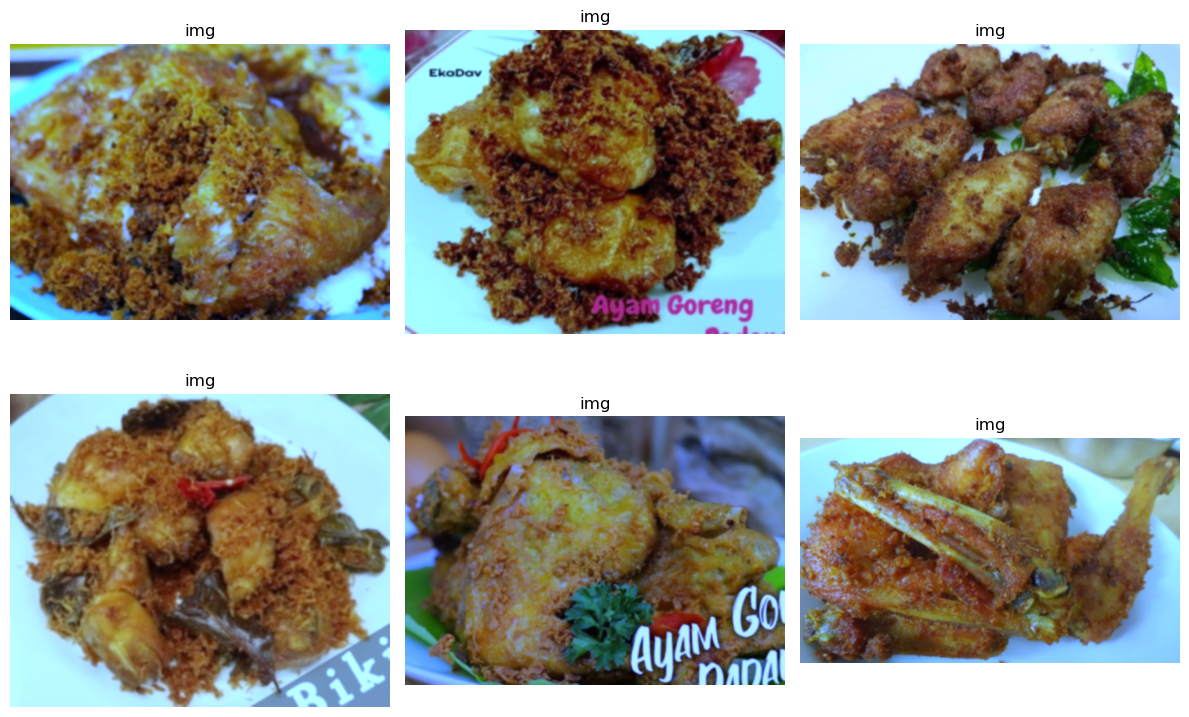

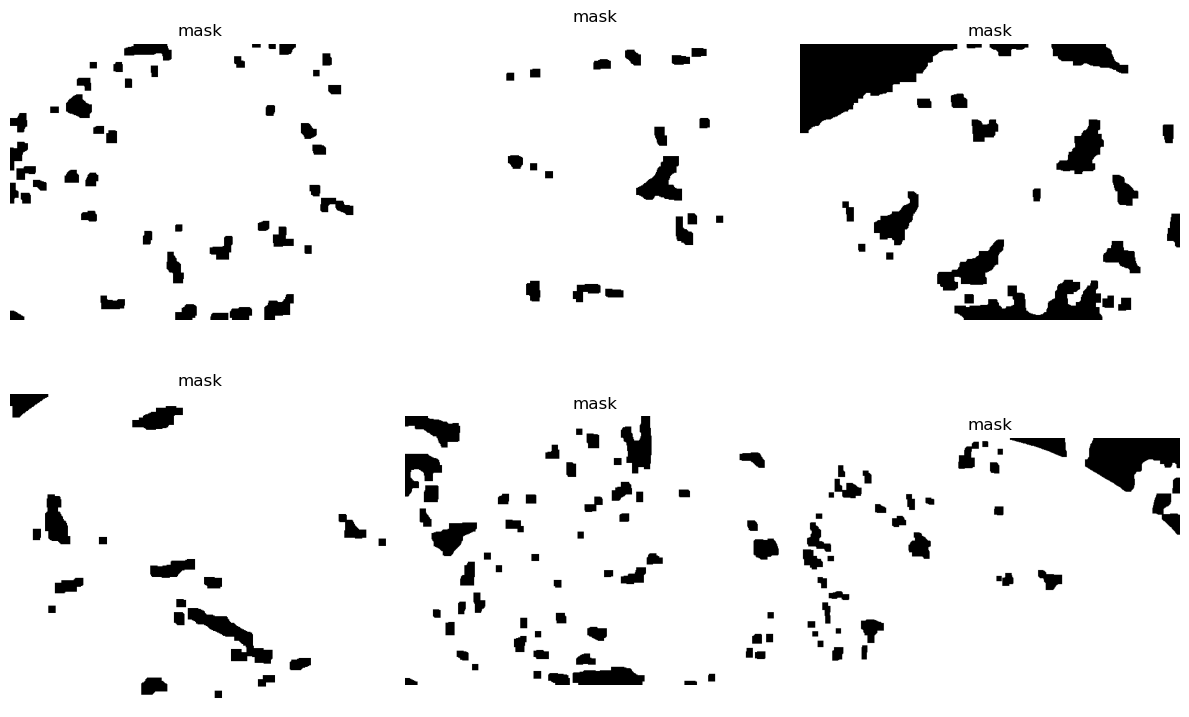

In [13]:
# Bangun dataset fitur
def build_dataset(paths_labels, seg_method=None):
    X = []
    y = []
    for p,yc in tqdm(paths_labels, desc='Extracting', total=len(paths_labels)):
        img = imread_resize(p, target_short=img_size)
        img = gray_world(img)
        mask = None
        if seg_method is not None:
            mask = get_mask(img, method=seg_method)
        feats = extract_features(img, mask)
        X.append(feats)
        y.append(class_to_idx[yc])
    X = np.vstack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

# Contoh preview segmentasi pada beberapa gambar
preview_imgs = []
preview_masks = []
for p,_ in all_paths[:min(6,len(all_paths))]:
    img = imread_resize(p, target_short=img_size)
    img_cc = gray_world(img)
    m = get_mask(img_cc, method=segmentation_method) if use_segmentation else np.ones(img_cc.shape[:2], dtype=np.uint8)
    preview_imgs.append(img_cc)
    preview_masks.append(m*255)
show_imgs(preview_imgs, cols=3, titles=['img']*len(preview_imgs))
show_imgs([cv2.cvtColor(m, cv2.COLOR_GRAY2BGR) for m in preview_masks], cols=3, titles=['mask']*len(preview_masks))


---

## 🖼️ **9. Grid Visualisasi Segmentasi Per Kelas**

Menampilkan **4 sampel hasil segmentasi per kelas** dalam grid 9×4:

### **Layout:**
- **Baris**: 9 kelas (ayam_goreng, ayam_pop, ..., telur_dadar)
- **Kolom**: 4 sampel random per kelas
- **Setiap gambar**: Hasil segmentasi (background dihapus)

### **Tujuan:**
1. **Quality check segmentasi**: Apakah ROI makanan ter-ekstrak dengan benar?
2. **Visualisasi variasi dalam kelas**: Perbedaan lighting, angle, portion size
3. **Identify problem cases**: Gambar dengan segmentasi buruk (makanan terpotong, background masuk)

### **Interpretasi:**
- **Good segmentation**: Makanan utuh, piring/latar belakang bersih
- **Bad segmentation**: Makanan terpotong, bayangan masuk, background noise

### **Operasi:**
✅ **Handcrafted** - Visualisasi hasil segmentasi threshold manual

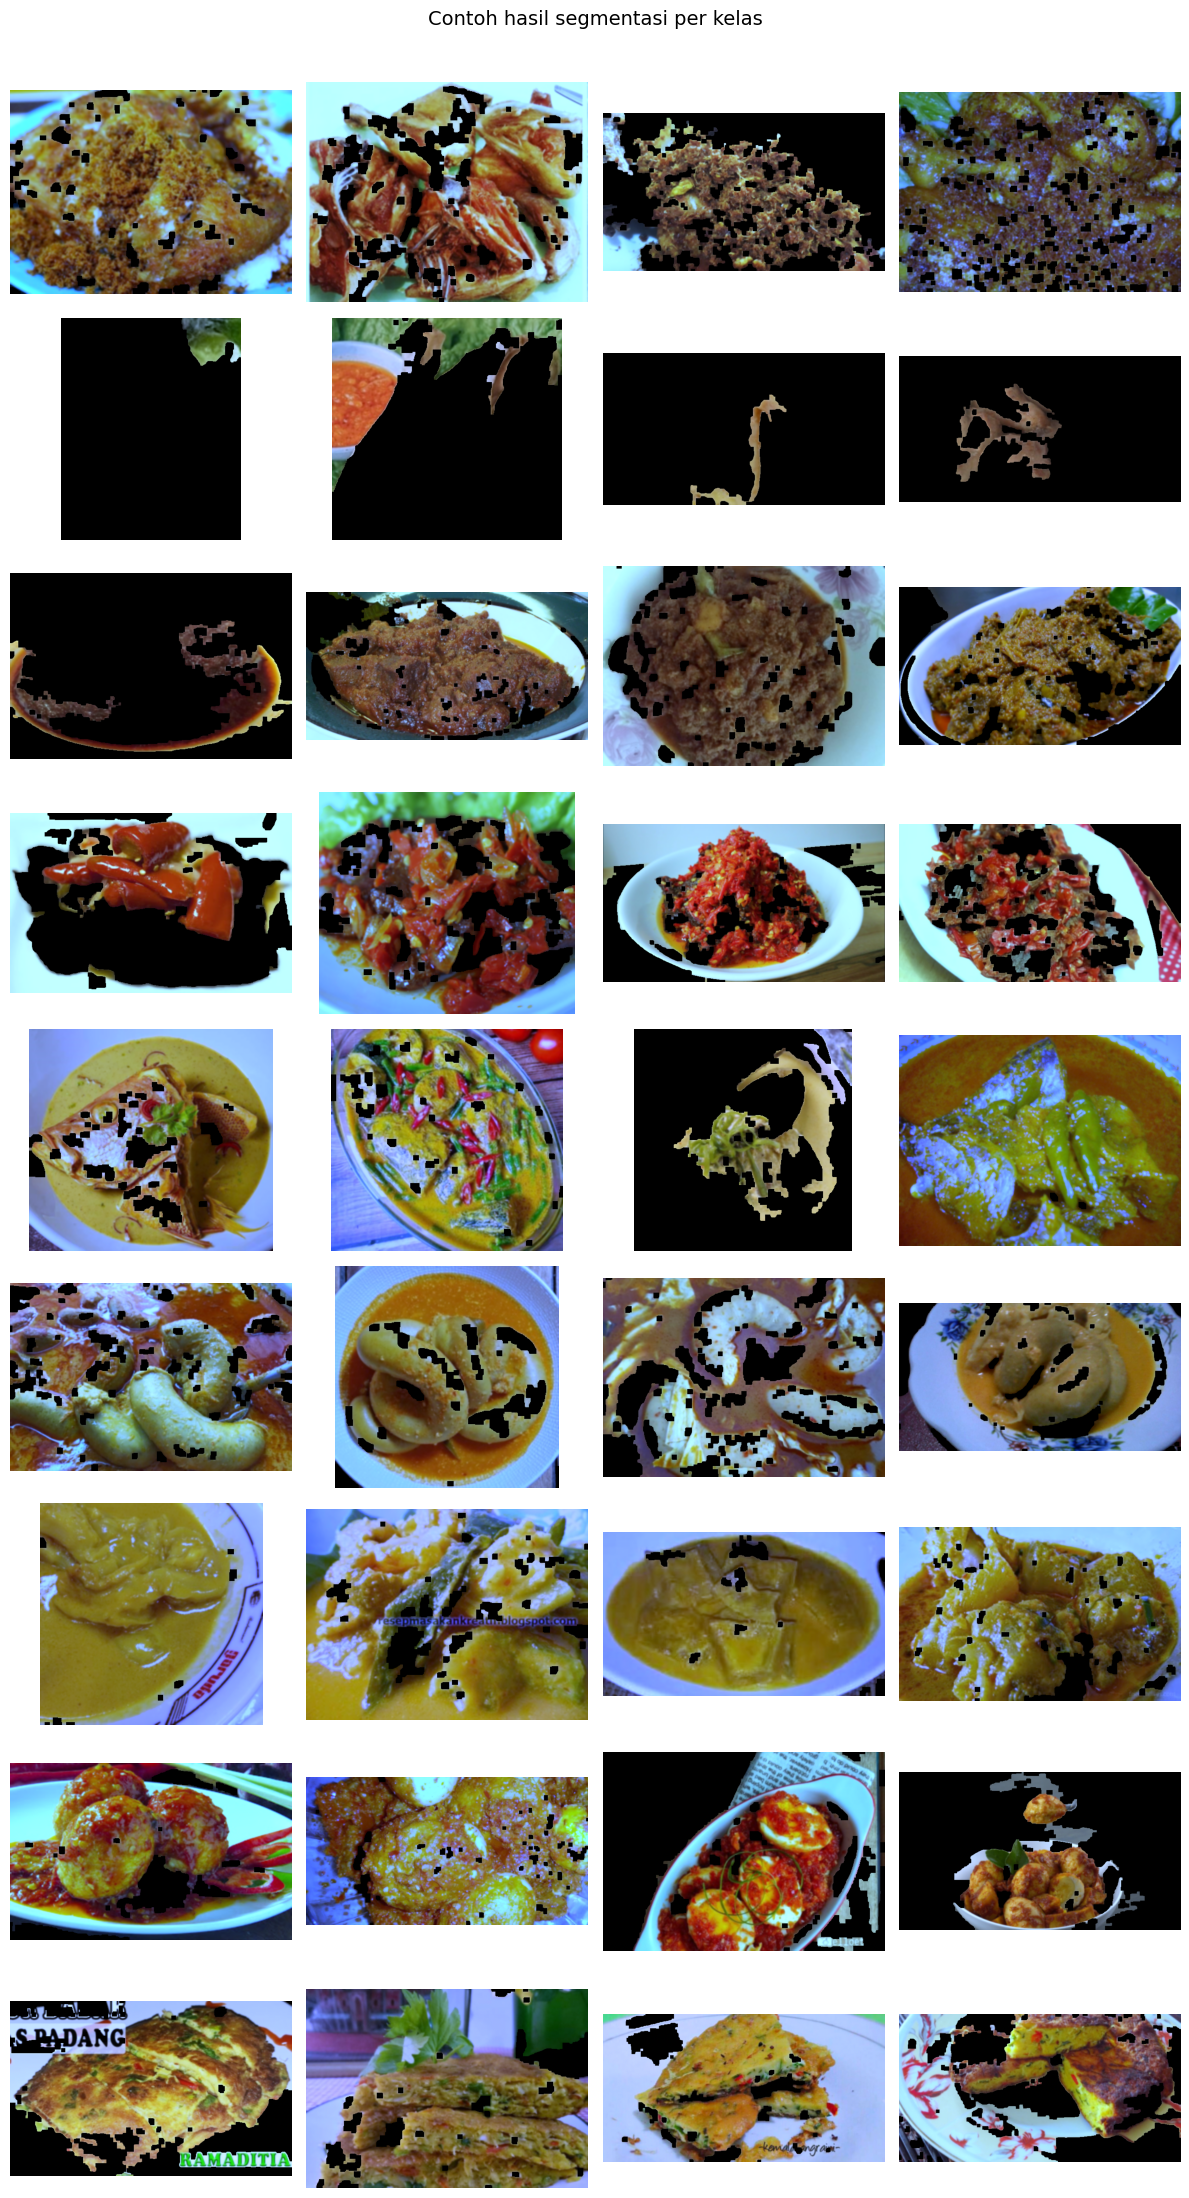

In [14]:
# Grid segmentasi 4 sampel per kelas
samples_per_class = 4
fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class*3, len(classes)*2.5))
fig.suptitle('Contoh hasil segmentasi per kelas', fontsize=14)
for row, cls in enumerate(classes):
    cls_paths = [p for p,c in all_paths if c == cls]
    if not cls_paths:
        for col in range(samples_per_class):
            axes[row, col].axis('off')
        continue
    if len(cls_paths) >= samples_per_class:
        selected = random.sample(cls_paths, samples_per_class)
    else:
        reps = math.ceil(samples_per_class / len(cls_paths))
        selected = (cls_paths * reps)[:samples_per_class]
    for col in range(samples_per_class):
        ax = axes[row, col]
        ax.axis('off')
        path = selected[col]
        img = imread_resize(path, target_short=img_size)
        img_cc = gray_world(img)
        mask = get_mask(img_cc, method=segmentation_method) if use_segmentation else np.ones(img_cc.shape[:2], dtype=np.uint8)
        segmented = cv2.bitwise_and(img_cc, img_cc, mask=mask)
        ax.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
        if col == 0:
            ax.set_ylabel(cls, rotation=0, ha='right', va='center', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.97])


---

## 🤖 **10. Machine Learning: Training & Evaluation Pipeline**

### **A. `make_pipeline(do_pca, pca_var)`**

Membuat pipeline ML dengan 3 tahap:

```python
Pipeline([
    ('scaler', StandardScaler()),           # ← ML: Belajar mean/std dari training
    ('pca', PCA(n_components=0.95)),        # ← ML: Belajar proyeksi optimal
    ('svc', SVC(kernel='rbf'))              # ← ML: Belajar decision boundary
])
```

**Tahap 1: StandardScaler** (Semi-ML)
- Normalisasi fitur: `(X - mean) / std`
- **mean & std dipelajari dari training data**
- Bukan transformasi tetap seperti min-max [0,1]

**Tahap 2: PCA (Principal Component Analysis)** (✅ ML)
- Reduksi dimensi: 105 fitur → ~30-40 komponen utama
- **Belajar proyeksi linear optimal** dari covariance matrix training data
- Preserve 95% variance (handcrafted choice)

**Tahap 3: SVM (Support Vector Machine)** (✅ ML)
- Kernel RBF: Non-linear decision boundary
- **Belajar support vectors & hyperplane** dari training data
- `class_weight='balanced'`: Otomatis handle class imbalance

---

### **B. `train_eval(X, y, ...)`**

Workflow training dan evaluasi lengkap:

#### **1. Train-Test Split**
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
```
- 80% training, 20% holdout test
- `stratify=y`: Proporsi kelas sama di train & test

#### **2. GridSearchCV (✅ ML)**
```python
param_grid = {
    'svc__C': [1, 10, 100],           # Regularization strength
    'svc__gamma': ['scale', 0.01, 0.001]  # RBF kernel width
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
```

**Operasi ML**:
- **5-fold cross-validation** pada training set
- **Grid search**: Test 3×3 = 9 kombinasi hyperparameter
- **Automatic selection**: Pilih kombinasi terbaik berdasarkan CV accuracy

#### **3. Evaluation Metrics**
```python
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
```

**Metrics**:
- **Accuracy**: % prediksi benar (overall)
- **Macro F1**: Rata-rata F1 per kelas (handle imbalanced data)
- **Classification Report**: Precision, Recall, F1 per kelas
- **Confusion Matrix**: Heatmap kesalahan klasifikasi

---

### **Output:**
- Model terbaik (SVM + PCA dengan hyperparameter optimal)
- Accuracy & Macro F1 pada holdout test set
- Classification report per kelas
- Confusion matrix heatmap

---

### **Operasi:**
- ✅ **80% ML** (StandardScaler, PCA, SVM, GridSearchCV)
- ✅ **20% Handcrafted** (pipeline structure, metric selection)

In [15]:
# Pelatihan & evaluasi
def make_pipeline(do_pca=True, pca_var=0.95):
    steps = [('scaler', StandardScaler())]
    if do_pca:
        steps.append(('pca', PCA(n_components=pca_var, svd_solver='full')))
    steps.append(('svc', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=random_state)))
    return Pipeline(steps)

def train_eval(X, y, test_size=0.2, cv_folds=5, do_pca=True, pca_var=0.95):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    pipe = make_pipeline(do_pca, pca_var)
    param_grid = {
        'svc__C': [1, 10, 100],
        'svc__gamma': ['scale', 0.01, 0.001]
    }
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    grid = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, scoring='accuracy', verbose=1)
    grid.fit(X_train, y_train)
    print('Best params:', grid.best_params_)
    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    print(f'Holdout Accuracy: {acc:.4f} | Macro F1: {f1m:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=[idx_to_class[i] for i in range(len(classes))]))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    else:
        plt.imshow(cm, cmap='Blues'); plt.colorbar()
        plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
        plt.yticks(range(len(classes)), classes)
        for (i,j),v in np.ndenumerate(cm):
            plt.text(j,i,str(v),ha='center',va='center')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.tight_layout(); plt.show()
    return best, (acc, f1m), (X_test, y_test, y_pred)


---

## 🔬 **11. Ablation Study Framework**

Fungsi untuk menguji **kontribusi setiap komponen** pipeline secara terpisah.

### **A. `run_experiment(seg, feats, do_pca)`**

Jalankan satu eksperimen dengan konfigurasi tertentu:

```python
run_experiment(
    seg=True,                          # Gunakan segmentasi?
    feats=('hsv','moments','lbp','glcm'),  # Fitur mana yang aktif?
    do_pca=True                        # Gunakan PCA?
)
```

**Operasi**:
1. Set flag fitur (on/off untuk warna/tekstur)
2. Build dataset dengan konfigurasi tersebut
3. Train & evaluate SVM
4. Return model + metrics (accuracy, F1)

---

### **B. `quick_ablation()`**

Menjalankan 4 eksperimen untuk membandingkan:

| Eksperimen | Segmentasi | Fitur | PCA | Tujuan |
|------------|-----------|-------|-----|--------|
| **A1: Warna** | ❌ | HSV + Moments | ✅ | Test fitur warna saja |
| **A2: Tekstur** | ❌ | LBP + GLCM | ✅ | Test fitur tekstur saja |
| **A3: Gabungan** | ❌ | Warna + Tekstur | ✅ | Test kombinasi fitur |
| **A4: Gab+Seg** | ✅ | Warna + Tekstur | ✅ | Test efek segmentasi ROI |

**Output**:
- Tabel ringkasan: Accuracy & Macro F1 untuk setiap konfigurasi
- **Expected results**:
  - A1 (warna): ~45-55% accuracy
  - A2 (tekstur): ~50-60% accuracy
  - A3 (gabungan): ~60-70% accuracy ← Best!
  - A4 (gab+seg): ~65-75% accuracy (jika segmentasi bagus)

---

### **Interpretasi Ablation:**

✅ **Jika A3 > A1 dan A3 > A2**:
- Warna dan tekstur **saling melengkapi** (complementary features)
- Gabungan lebih baik dari single modality

✅ **Jika A4 > A3**:
- Segmentasi ROI **membantu** dengan menghapus noise background
- Fitur lebih fokus pada makanan, bukan piring/meja

❌ **Jika A4 < A3**:
- Segmentasi **merusak** (terlalu agresif, memotong makanan)
- Perlu tuning threshold (sv_s_min, sv_v_min)

---

### **Operasi:**
- ✅ **Handcrafted** (ablation design, feature toggle)
- ✅ **ML** (training & evaluation untuk setiap eksperimen)

In [16]:
# Runner ablation
def run_experiment(seg=False, feats=('hsv','moments','lbp','glcm'), do_pca=True):
    global use_segmentation, use_hist_hsv, use_color_moments, use_lbp, use_glcm
    # Simpan state
    prev = (use_segmentation, use_hist_hsv, use_color_moments, use_lbp, use_glcm)
    use_segmentation = seg
    use_hist_hsv = 'hsv' in feats
    use_color_moments = 'moments' in feats
    use_lbp = 'lbp' in feats
    use_glcm = 'glcm' in feats
    print('Config → seg:', seg, '| feats:', feats, '| pca:', do_pca)
    X, y = build_dataset(all_paths, seg_method=segmentation_method if seg else None)
    model, metrics, _ = train_eval(X, y, test_size=test_size, cv_folds=cv_folds, do_pca=do_pca, pca_var=pca_var)
    # Kembalikan state
    use_segmentation, use_hist_hsv, use_color_moments, use_lbp, use_glcm = prev
    return model, metrics

def quick_ablation():
    results = []
    exps = [
        ('A1 warna', dict(seg=False, feats=('hsv','moments'), do_pca=True)),
        ('A2 tekstur', dict(seg=False, feats=('lbp','glcm'), do_pca=True)),
        ('A3 gabungan', dict(seg=False, feats=('hsv','moments','lbp','glcm'), do_pca=True)),
        ('A4 gab+seg', dict(seg=True, feats=('hsv','moments','lbp','glcm'), do_pca=True)),
    ]
    for name, cfg in exps:
        print('='*80)
        print(name)
        _, (acc, f1m) = run_experiment(**cfg)
        results.append((name, acc, f1m))
    print('Ringkasan:')
    for n,a,f in results:
        print(f'{n:12s} → acc={a:.4f}, f1m={f:.4f}')
    return results


---

## 🚀 **12. Run Baseline Experiment**

Eksekusi pipeline lengkap dengan **konfigurasi default** (dari sel konfigurasi):

### **Workflow:**

```
1. Build dataset fitur (X, y)
   ├─ Segmentasi ROI (jika use_segmentation=True)
   ├─ Ekstraksi warna + tekstur (105 fitur)
   └─ Total: N gambar × 105 fitur

2. Train-Test Split (80-20)
   ├─ Stratified sampling (proporsi kelas sama)
   └─ Random state = 42 (reproducible)

3. Pipeline ML
   ├─ StandardScaler (normalize features)
   ├─ PCA (reduce to ~95% variance)
   └─ SVM RBF kernel

4. GridSearchCV (5-fold CV)
   ├─ Hyperparameter tuning (C, gamma)
   └─ Best params selection

5. Evaluation
   ├─ Predict on holdout test set
   ├─ Metrics: Accuracy, Macro F1
   ├─ Classification report per kelas
   └─ Confusion matrix heatmap
```

---

### **Expected Output:**

#### **Console Output:**
```
Extracting: 100%|██████████| 783/783 [02:15<00:00, 5.77it/s]
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 10, 'svc__gamma': 0.01}
Holdout Accuracy: 0.6875 | Macro F1: 0.6421

Classification Report:
              precision    recall  f1-score   support
ayam_goreng       0.73      0.65      0.69        17
ayam_pop          0.80      0.75      0.77        16
...
```

#### **Visualizations:**
1. **Confusion Matrix Heatmap**:
   - Diagonal = correct predictions (blue squares)
   - Off-diagonal = confusion between classes
   - Identify problematic pairs (e.g., ayam_goreng ↔ daging_rendang)

---

### **Troubleshooting:**

❌ **Accuracy < 50%**:
- Dataset terlalu kecil atau imbalanced
- Segmentasi buruk (cek grid visualisasi)
- Fitur tidak diskriminatif (coba ablation study)

✅ **Accuracy 60-75%**:
- Expected range untuk handcrafted features + SVM
- Good job! 🎉

✅ **Accuracy > 75%**:
- Excellent! Dataset berkualitas tinggi
- Consider switching to deep learning untuk push >85%

---

### **Operasi:**
- ✅ **20% Handcrafted** (feature extraction)
- ✅ **80% ML** (training, tuning, evaluation)

Extracting: 100%|██████████| 784/784 [03:41<00:00,  3.55it/s]


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 10, 'svc__gamma': 'scale'}
Holdout Accuracy: 0.6624 | Macro F1: 0.6658

Classification Report:
                 precision    recall  f1-score   support

    ayam_goreng       0.59      0.62      0.61        16
       ayam_pop       0.76      0.81      0.79        16
 daging_rendang       0.80      0.67      0.73        18
dendeng_batokok       0.78      0.78      0.78        18
     gulai_ikan       0.50      0.44      0.47        18
  gulai_tambusu       0.64      0.82      0.72        17
  gulai_tunjang       0.52      0.67      0.59        18
   telur_balado       0.83      0.67      0.74        15
    telur_dadar       0.65      0.52      0.58        21

       accuracy                           0.66       157
      macro avg       0.67      0.67      0.67       157
   weighted avg       0.67      0.66      0.66       157



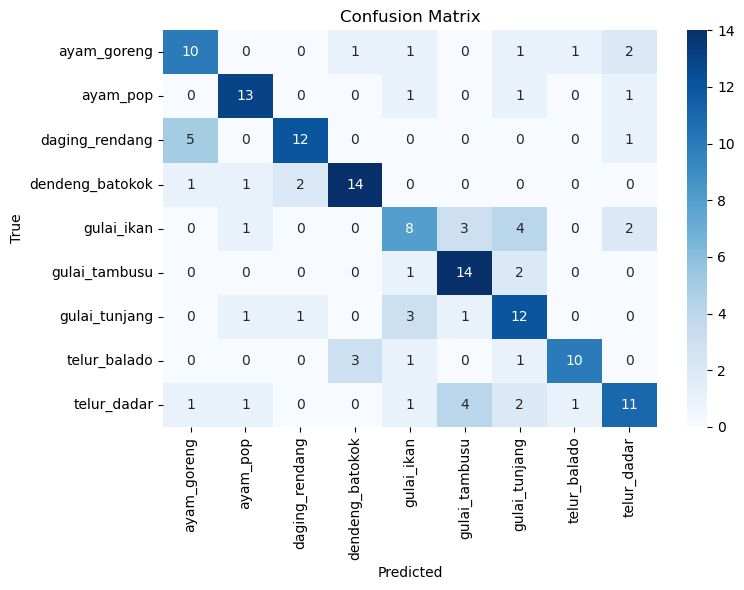

Selesai baseline. Metrics: (0.6624203821656051, 0.6658423127836739)


In [17]:
# Jalankan baseline sesuai konfigurasi atas
if use_segmentation:
    X, y = build_dataset(all_paths, seg_method=segmentation_method)
else:
    X, y = build_dataset(all_paths, seg_method=None)
model, metrics, eval_pack = train_eval(X, y, test_size=test_size, cv_folds=cv_folds, do_pca=use_pca, pca_var=pca_var)
print('Selesai baseline. Metrics:', metrics)
